# EDA Case Study: Ice Cream Shop Sales (Beginner Edition)

Exploratory Data Analysis (EDA) simply means **looking closely at your data before drawing any
conclusions from it** — checking what's there, fixing anything messy, and looking for simple
patterns. This notebook walks through a short, beginner-friendly EDA pass on one month of a
small ice cream shop's daily sales, using the same NumPy, Pandas, and visualization tools from
the earlier Day-4 notebooks.

1. Introduction to EDA & the Dataset
2. Load & Look at the Data
3. Clean the Data
4. Explore One Column at a Time
5. Explore Two Columns Together
6. What Did We Learn?

## 1. Introduction to EDA & the Dataset

A simple EDA workflow: **load the data → look at it → clean it up → look at one column at a
time → look at two columns together → write down what you found.**

The dataset below is made up (so this notebook needs no file or internet access), but it behaves
like a real one: **warmer days sell more ice cream** — a simple, easy-to-spot pattern, which is
exactly the kind of thing EDA is meant to uncover. A couple of missing values and one duplicate
row are added on purpose, so Section 3 has some real cleaning to do.

## 2. Load & Look at the Data

Each row is one day at the shop:
- `date` — the day
- `day_of_week` — name of the day
- `temperature_c` — that day's high temperature, in Celsius
- `flavor` — that day's best-selling flavor
- `units_sold` — how many ice creams were sold that day

In [1]:
# Solution
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
np.random.seed(1)

n_days = 30
date = pd.date_range("2026-06-01", periods=n_days, freq="D")
day_of_week = date.day_name()
temperature_c = np.random.randint(18, 38, size=n_days)  # daily high temperature, in Celsius
flavor = np.random.choice(["Vanilla", "Chocolate", "Strawberry", "Mint"], size=n_days)

# Warmer days sell more ice cream — one simple, easy-to-read formula
units_sold = (temperature_c * 3 + np.random.randint(-10, 10, size=n_days)).clip(min=0)

ice_cream_df = pd.DataFrame({
    "date": date,
    "day_of_week": day_of_week,
    "temperature_c": temperature_c,
    "flavor": flavor,
    "units_sold": units_sold,
})

# Real datasets are rarely perfectly clean — add a couple of missing values and one duplicate row
missing_idx = np.random.choice(ice_cream_df.index, size=2, replace=False)
ice_cream_df.loc[missing_idx, "units_sold"] = np.nan
ice_cream_df = pd.concat([ice_cream_df, ice_cream_df.iloc[[5]]], ignore_index=True)

print("shape:", ice_cream_df.shape)
ice_cream_df.head()

shape: (31, 5)


,date,day_of_week,temperature_c,flavor,units_sold
0,2026-06-01,Monday,23,Mint,75.0
1,2026-06-02,Tuesday,29,Chocolate,90.0
2,2026-06-03,Wednesday,30,Strawberry,99.0
3,2026-06-04,Thursday,26,Chocolate,77.0
4,2026-06-05,Friday,27,Chocolate,89.0


In [2]:
# Solution
ice_cream_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           31 non-null     datetime64[us]
 1   day_of_week    31 non-null     str           
 2   temperature_c  31 non-null     int32         
 3   flavor         31 non-null     str           
 4   units_sold     29 non-null     float64       
dtypes: datetime64[us](1), float64(1), int32(1), str(2)
memory usage: 1.2 KB


## 3. Clean the Data

Check for missing values and duplicate rows, then fix both: drop the duplicate row, and fill the
missing `units_sold` values with the column's average (a simple, reasonable stand-in when the
real number isn't known).

In [3]:
# Solution
print("missing values per column:\n", ice_cream_df.isna().sum())
print("\nduplicate rows:", ice_cream_df.duplicated().sum())

before_shape = ice_cream_df.shape
ice_cream_df = ice_cream_df.drop_duplicates().reset_index(drop=True)

average_units = ice_cream_df["units_sold"].mean()
ice_cream_df["units_sold"] = ice_cream_df["units_sold"].fillna(average_units).round(0)

print(f"\nshape before cleaning: {before_shape}  ->  after cleaning: {ice_cream_df.shape}")
print("remaining missing values:", ice_cream_df.isna().sum().sum())

missing values per column:
 date             0
day_of_week      0
temperature_c    0
flavor           0
units_sold       2
dtype: int64

duplicate rows: 1

shape before cleaning: (31, 5)  ->  after cleaning: (30, 5)
remaining missing values: 0


## 4. Explore One Column at a Time (Univariate)

Look at the numeric columns with `describe()`, the categorical column with `value_counts()`,
and then plot each: a histogram for `units_sold`, and a count plot for `flavor`.

       temperature_c  units_sold
count      30.000000   30.000000
mean       27.766667   82.633333
std         5.184083   16.570608
min        18.000000   51.000000
25%        24.250000   70.250000
50%        27.500000   85.500000
75%        31.000000   92.750000
max        36.000000  117.000000

how many days each flavor was the best seller:
 flavor
Chocolate     10
Vanilla        8
Mint           7
Strawberry     5
Name: count, dtype: int64


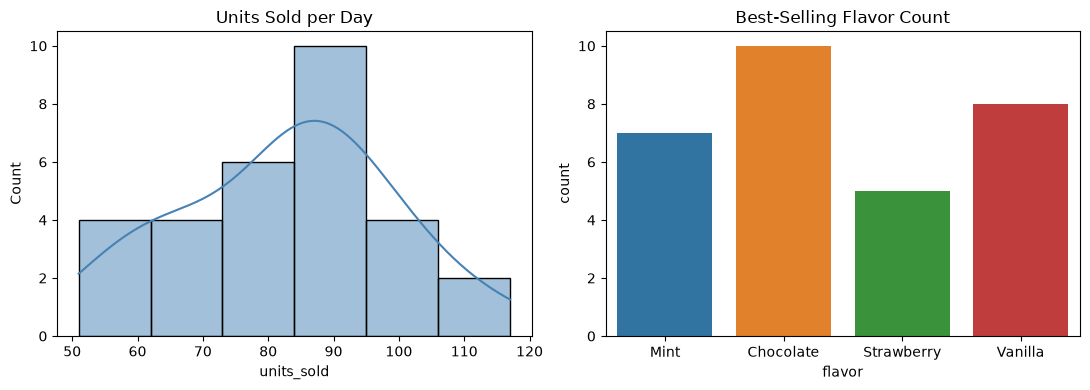

In [4]:
# Solution
print(ice_cream_df[["temperature_c", "units_sold"]].describe())
print("\nhow many days each flavor was the best seller:\n", ice_cream_df["flavor"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(ice_cream_df["units_sold"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Units Sold per Day")
sns.countplot(data=ice_cream_df, x="flavor", ax=axes[1], hue="flavor", legend=False)
axes[1].set_title("Best-Selling Flavor Count")
plt.tight_layout()
plt.show()

## 5. Explore Two Columns Together (Bivariate)

Now look at how two columns relate: a scatterplot of `temperature_c` vs. `units_sold` (does
selling go up on hotter days?), and the average `units_sold` for each best-selling `flavor`.

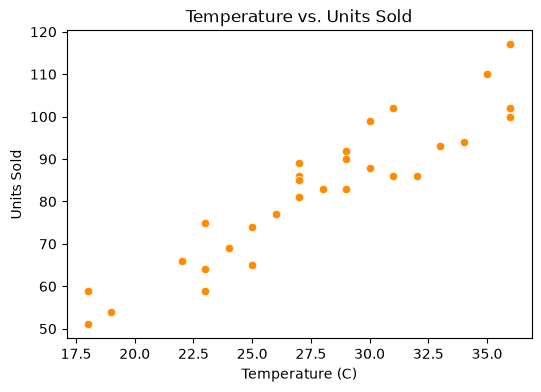

correlation between temperature and units sold: 0.93

average units sold on days each flavor was the best seller:
 flavor
Mint          86.3
Chocolate     82.6
Vanilla       81.5
Strawberry    79.4
Name: units_sold, dtype: float64


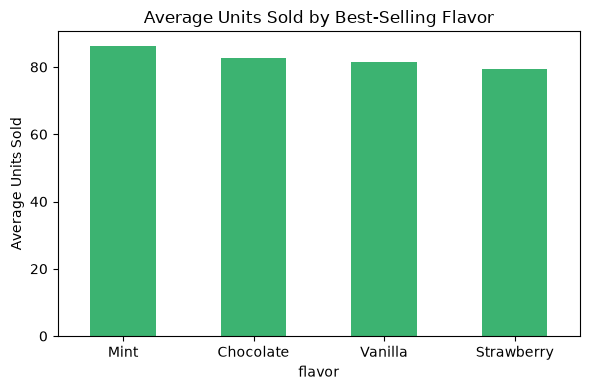

In [5]:
# Solution
plt.figure(figsize=(6, 4))
sns.scatterplot(data=ice_cream_df, x="temperature_c", y="units_sold", color="darkorange")
plt.title("Temperature vs. Units Sold")
plt.xlabel("Temperature (C)")
plt.ylabel("Units Sold")
plt.show()

correlation = ice_cream_df["temperature_c"].corr(ice_cream_df["units_sold"])
print(f"correlation between temperature and units sold: {correlation:.2f}")

avg_by_flavor = ice_cream_df.groupby("flavor")["units_sold"].mean().sort_values(ascending=False)
print("\naverage units sold on days each flavor was the best seller:\n", avg_by_flavor.round(1))

avg_by_flavor.plot(kind="bar", color="mediumseagreen", figsize=(6, 4))
plt.title("Average Units Sold by Best-Selling Flavor")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. What Did We Learn?

Wrap up with a few plain-language takeaways, backed by the numbers computed above.

In [6]:
# Solution
top_flavor = avg_by_flavor.index[0]
top_flavor_avg = avg_by_flavor.iloc[0]

print(f"1. Temperature and units sold tend to move together (correlation = {correlation:.2f}) "
      "- warmer days sold more ice cream.")
print(f"2. '{top_flavor}' had the highest average units sold ({top_flavor_avg:.1f} per day) "
      "among best-selling flavors.")
print(f"3. Takeaway: stock more ice cream - especially '{top_flavor}' - when the forecast is hot.")

1. Temperature and units sold tend to move together (correlation = 0.93) - warmer days sold more ice cream.
2. 'Mint' had the highest average units sold (86.3 per day) among best-selling flavors.
3. Takeaway: stock more ice cream - especially 'Mint' - when the forecast is hot.
